In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, kstest

In [116]:
df = pd.read_csv('../data/youtube_clean.csv')

numerical_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width',
                  'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']

df

,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),codec,category,title,description,hashtags,views,likes,comments
0,180,"5,777.00","5,640.00",1920,1080,25.00,25.00,h264,News & Politics,«السودان ينتفض» أمام السفارة بالقاهرة,حرية سلام وعدالة، الثورة خيار الشعب.. بهذا اله...,"في, عسكري, حكم, حرية, بخصوص, المصري اليوم, الس...",4078,41,3
1,930,"1,195.00","1,001.00",1280,720,30.00,30.00,h264,Gaming,Pokemon Tower Defense Episodio 2,Espero que tenham gostado do video!,"Pokémon (Anime/Manga Franchise), Pokémon (Vide...",33,2,1
2,233,"3,028.00","2,833.00",1280,720,23.98,23.98,h264,Comedy,New Hip Hop - Kemo Treats - Pancakes,Download all our music for FREE just enter $0....,"breaking bad spoof, Recipes, Pancakes, canada,...",13227,135,17
3,562,431.00,300.00,320,240,29.97,0.00,h264,People & Blogs,Sister's Keeper Impression,A Review of the Shampoo Bar(Sunburst) and Dip ...,"natural hair, first impression, sister's keepe...",43,1,0
4,300,"3,087.00","2,929.00",1280,720,23.98,23.98,h264,Gaming,JBHAMMER777 (AKUMA) VS KtossPol Rank 1 (Vega)...,JBHAMMER777 is he strong enough to fight again...,"Tokido, momochi, (Ryu), AE, 11, at, Piyoppia, ...",222,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17581,571,"1,285.00","1,175.00",640,480,29.92,0.00,h264,People & Blogs,rentero 1ª parte 2.MOD,No description,"rentero, latapialinares, iu, pca",27,0,0
17582,105,840.00,719.00,640,480,29.97,0.00,h264,People & Blogs,Cascavel faz campanha impecável em campeonato ...,No description,No hashtags,295,1,0
17583,161,920.00,820.00,640,480,29.97,0.00,h264,People & Blogs,Marcha para Cristo.San Francisco Menéndez. 5 ...,No description,"Cristo, Marcha, para",770,3,0
17584,291,"4,892.00","4,738.00",1920,1080,29.97,29.97,h264,Gaming,DK Solo Steinerne Kern,"Das ist mein erstes Video, also ist noch alles...","Steinerne Kern, Vitriolsteindrachen, DK Solo, ...",42,1,0


In [117]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns
categorical_features

Index(['codec', 'category', 'title', 'description', 'hashtags'], dtype='object')

Range của các biến s

In [118]:
for col in numerical_cols:
    col_range = df[col].max() - df[col].min()
    print(f"Range của {col}: {col_range}")

Range của duration: 25844
Range của bitrate: 22380.0
Range của bitrate(video): 22228.0
Range của height: 2484
Range của width: 1856
Range của frame rate: 55.33
Range của frame rate(est.): 30.0
Range của views: 410384910
Range của likes: 836981
Range của comments: 16634


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
duration,"17,586.00",241.37,492.62,1.00,51.00,135.00,268.00,"25,845.00",16.99,603.88
bitrate,"17,586.00","1,271.61","1,375.36",41.00,437.00,743.75,"1,293.00","22,421.00",2.41,8.76
bitrate(video),"17,586.00","1,154.97","1,349.15",1.00,332.00,639.00,"1,184.00","22,229.00",2.46,9.22
height,"17,586.00",766.78,467.33,108.00,426.00,640.00,960.00,"2,592.00",1.12,0.47
width,"17,586.00",504.60,262.75,88.00,320.00,480.00,720.00,"1,944.00",1.30,2.31
frame rate,"17,586.00",26.47,6.04,3.75,25.00,29.97,29.97,59.08,-1.35,2.87
frame rate(est.),"17,586.00",9.47,13.25,0.00,0.00,0.00,25.00,30.00,0.75,-1.36


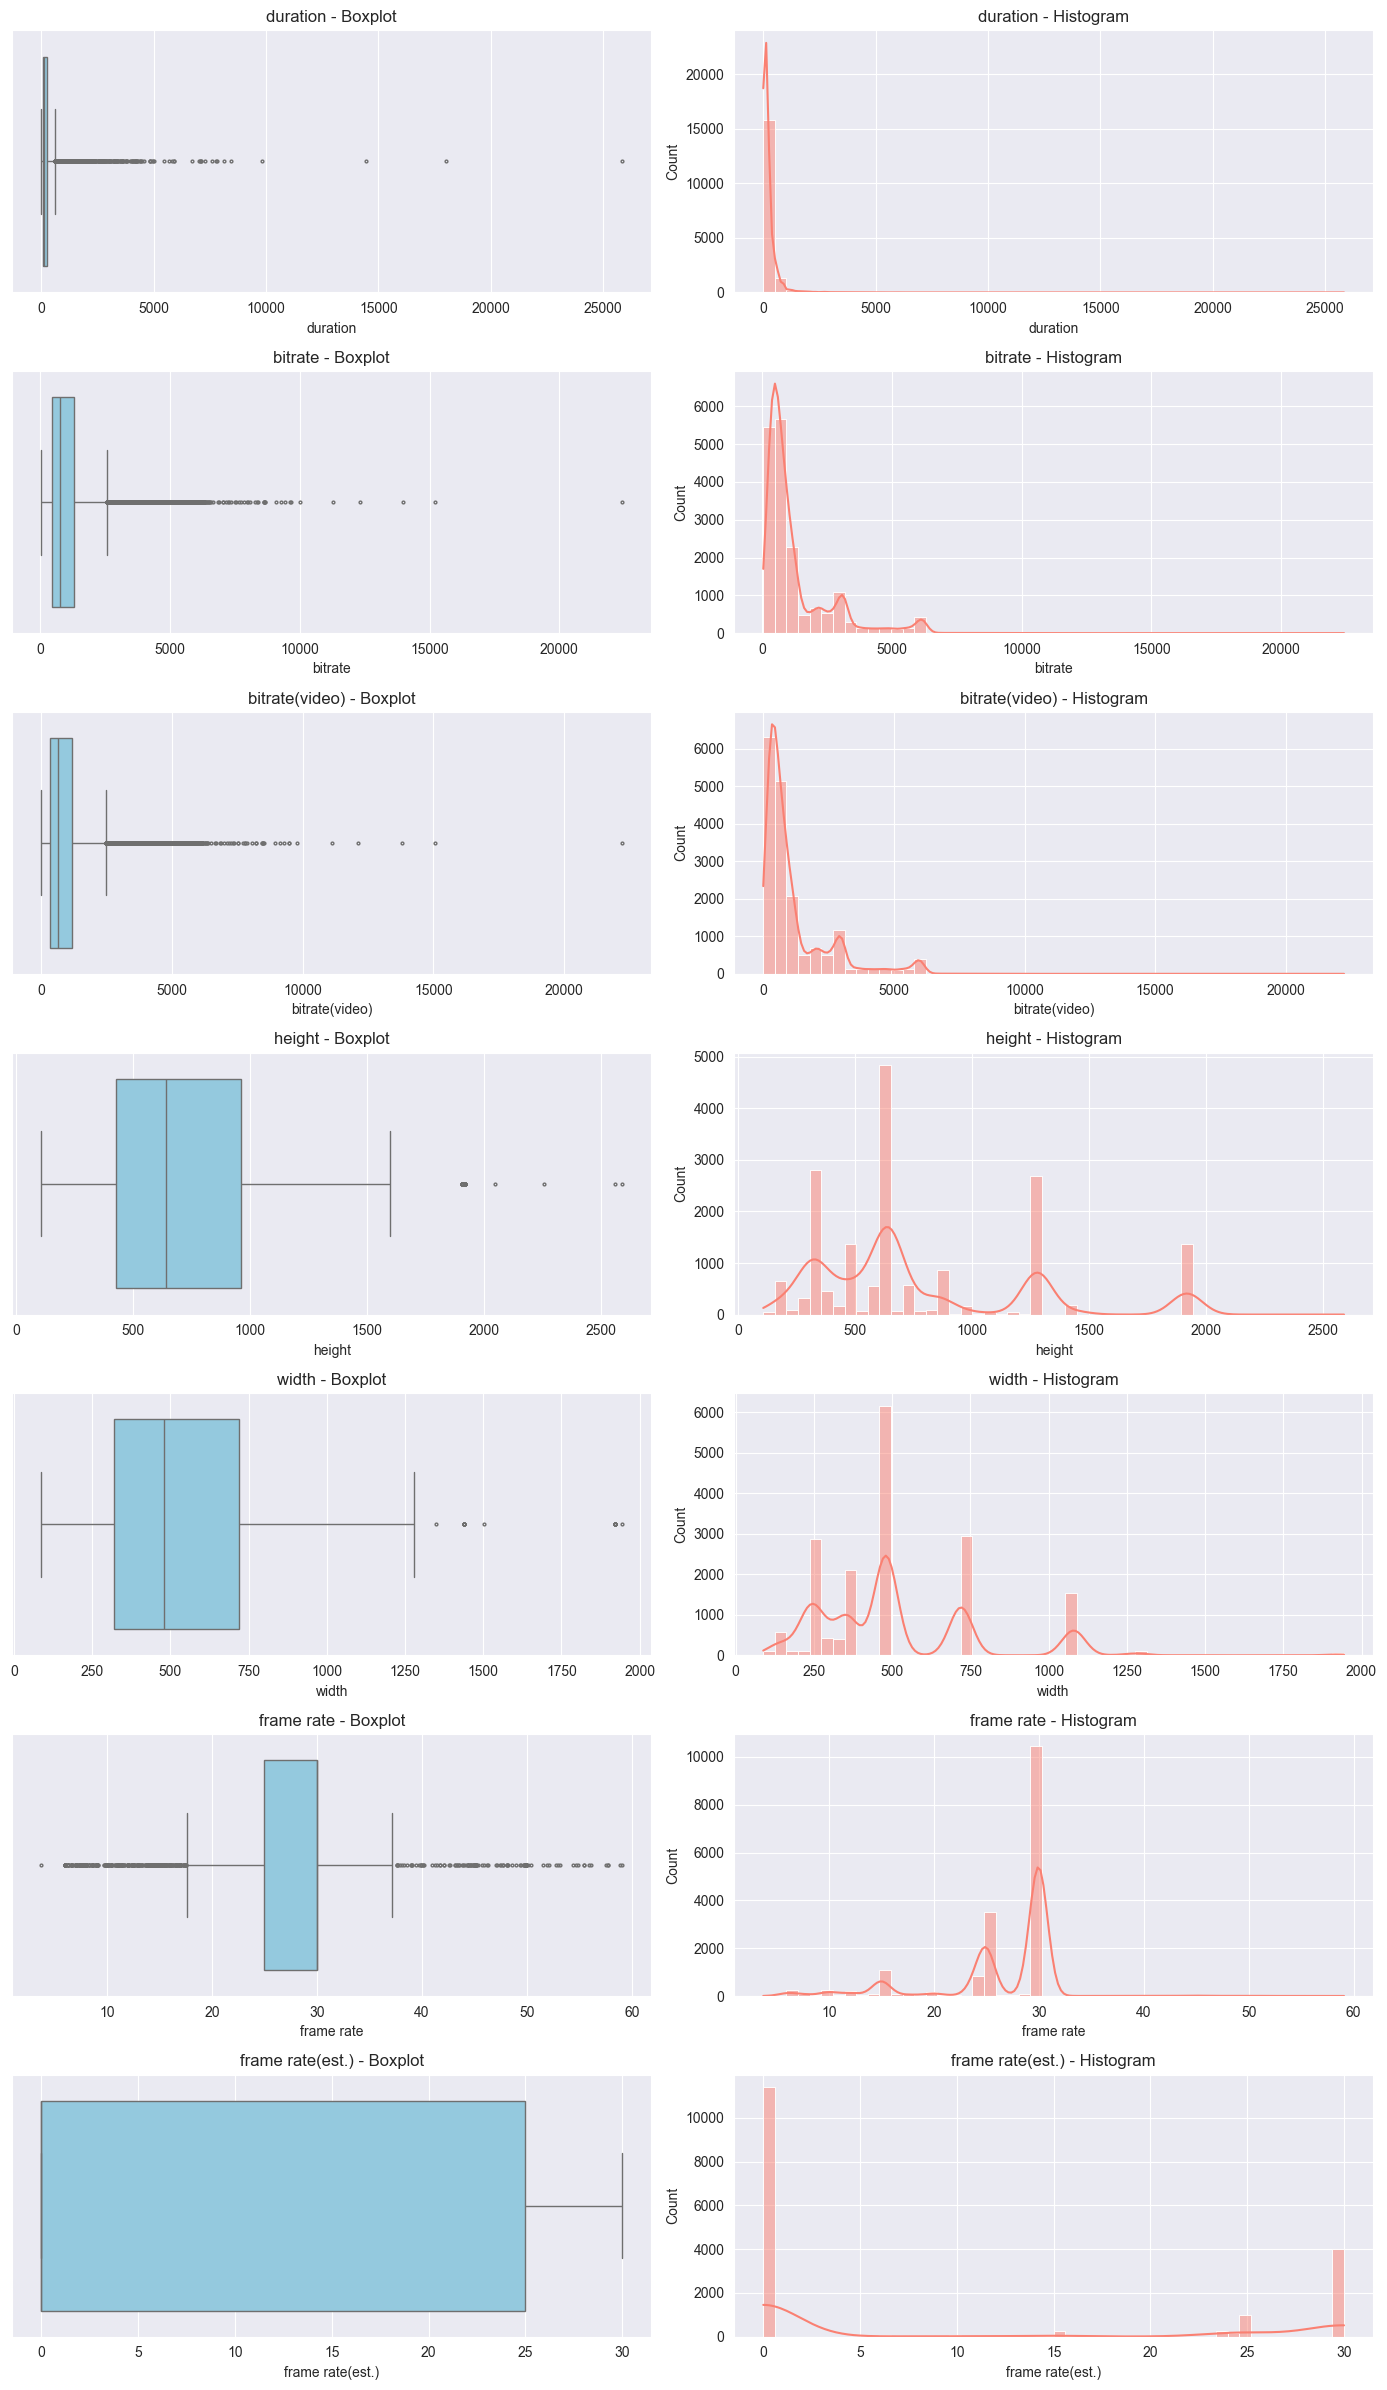

In [119]:
tech_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width', 'frame rate', 'frame rate(est.)']

tech_stats = df[tech_cols].describe().T
tech_stats['skewness'] = df[tech_cols].skew()
tech_stats['kurtosis'] = df[tech_cols].kurtosis()
display(tech_stats.round(3))

fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(14, 24))
for i, col in enumerate(tech_cols):
    sns.boxplot(x=df[col], ax=axes[i, 0], color='skyblue', fliersize=2)
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i, 1], color='salmon')
    axes[i, 0].set_title(f"{col} - Boxplot")
    axes[i, 1].set_title(f"{col} - Histogram")
plt.tight_layout()
plt.show()

In [120]:
for col in ['bitrate', 'bitrate(video)']:
    print(f"\n=== {col} ===")
    print(df[col].describe())
    print(f"Giá trị nhỏ nhất: {df[col].min()}")
    print(f"5 giá trị nhỏ nhất:\n{df[col].nsmallest(5).values}")


=== bitrate ===
count   17,586.00
mean     1,271.61
std      1,375.36
min         41.00
25%        437.00
50%        743.75
75%      1,293.00
max     22,421.00
Name: bitrate, dtype: float64
Giá trị nhỏ nhất: 41.0
5 giá trị nhỏ nhất:
[41. 47. 47. 49. 55.]

=== bitrate(video) ===
count   17,586.00
mean     1,154.97
std      1,349.15
min          1.00
25%        332.00
50%        639.00
75%      1,184.00
max     22,229.00
Name: bitrate(video), dtype: float64
Giá trị nhỏ nhất: 1.0
5 giá trị nhỏ nhất:
[1. 2. 2. 2. 3.]


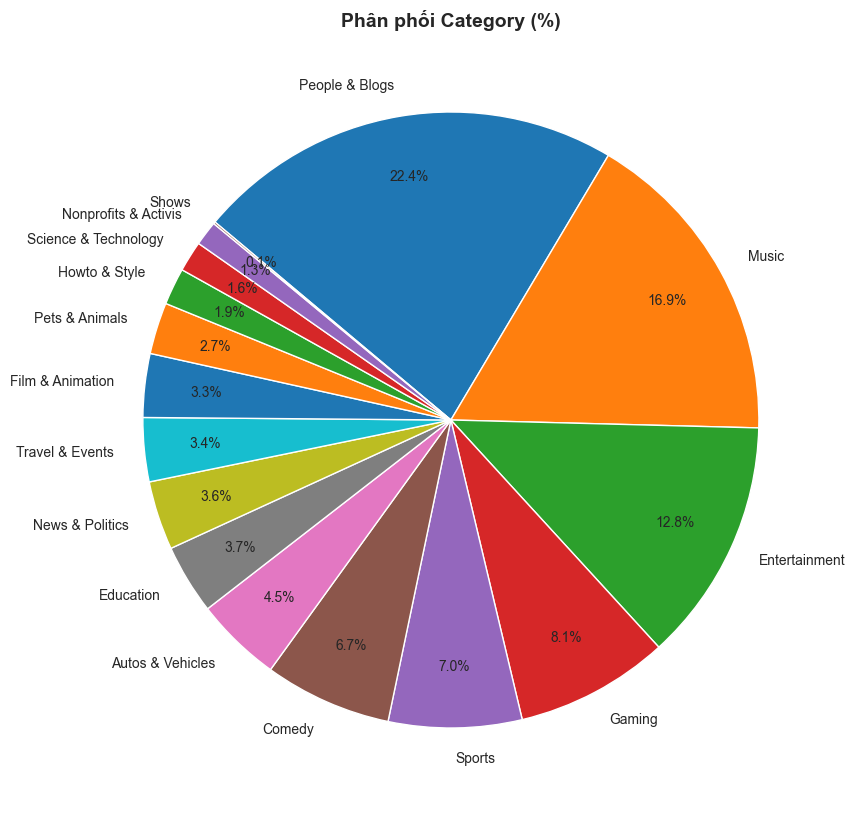

In [121]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10},
    labeldistance=1.1,
    pctdistance=0.8
)
plt.title('Phân phối Category (%)', fontsize=14, fontweight='bold')
plt.show()

In [122]:
codec_dist = (
    df['codec']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename('Percentage (%)')
    .to_frame()
)

codec_dist['Count'] = df['codec'].value_counts()

print(codec_dist)

       Percentage (%)  Count
codec                       
h264            99.67  17528
vp8              0.27     47
flv1             0.05      9
mpeg4            0.01      2


In [123]:
df['hashtags'] = df['hashtags'].astype(str).str.lower().str.strip()

df['hashtags'] = df['hashtags'].replace(
    ["", " ", "none", "nan", "null", "no hashtag", "no hashtags"],
    "no_hashtags"
)

/var/folders/06/55ncynjj69l30_gnnsnw6xv40000gn/T/ipykernel_12279/337767742.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




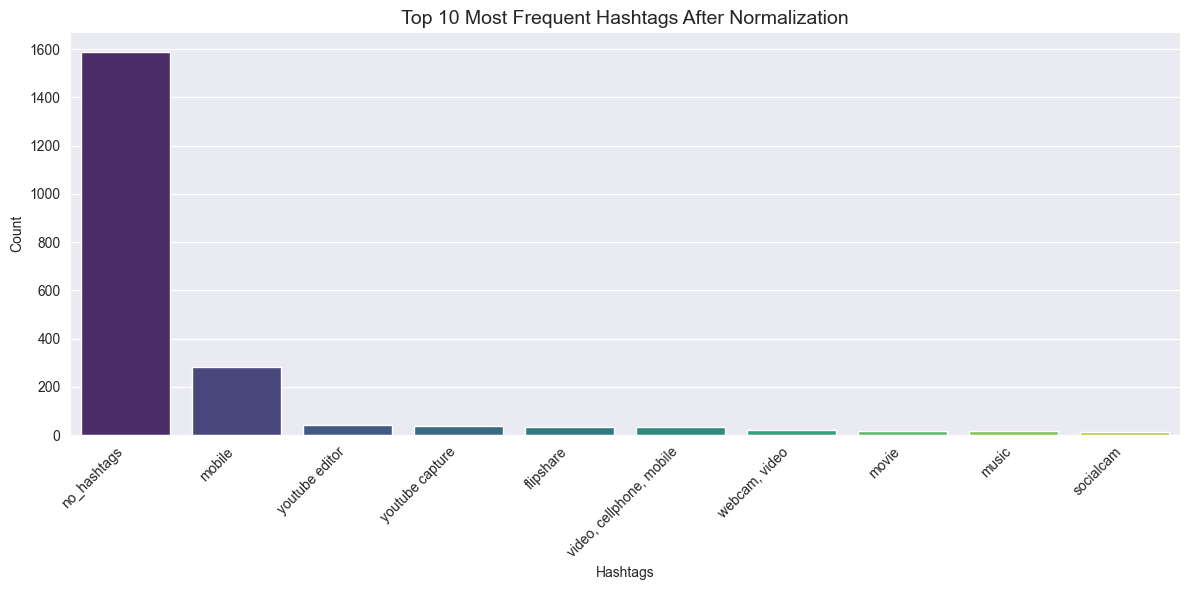

In [124]:
top10_hashtags = df['hashtags'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df[df['hashtags'].isin(top10_hashtags)],
    x='hashtags',
    order=top10_hashtags,
    palette='viridis'
)

plt.title("Top 10 Most Frequent Hashtags After Normalization", fontsize=14)
plt.xlabel("Hashtags")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [125]:
df['has_hashtags'] = df['hashtags'].apply(lambda x: 0 if x == 'no_hashtags' else 1)

# Tính ER trước nếu chưa có
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views'].replace(0, 1)

# Category performance
cat_mean = df.groupby('category')[['views', 'likes', 'comments', 'engagement_rate']].mean()

top_views_cat = cat_mean['views'].idxmax()
top_er_cat = cat_mean['engagement_rate'].idxmax()

# Video top views
top_video = df.loc[df['views'].idxmax()]

# Median indicators
median_views = df['views'].median()
median_likes = df['likes'].median()
median_comments = df['comments'].median()

# % video ER < 1%
low_er_pct = (df['engagement_rate'] < 0.01).mean() * 100

kpi_refined = {
    'Top Category by Views': top_views_cat,
    'Top Category by ER': top_er_cat,
    'Top Viewed Video': top_video['title'],
    'Top Video Category': top_video['category'],
    'Median Views': median_views,
    'Median Likes': median_likes,
    'Median Comments': median_comments,
    '% Videos ER < 1%': round(low_er_pct, 2)
}

kpi_refined

{'Top Category by Views': 'Education',
 'Top Category by ER': 'Gaming',
 'Top Viewed Video': 'Phonics Song',
 'Top Video Category': 'Education',
 'Median Views': np.float64(153.0),
 'Median Likes': np.float64(1.0),
 'Median Comments': np.float64(0.0),
 '% Videos ER < 1%': np.float64(75.11)}

In [126]:
zero_count = (df['frame rate(est.)'] == 0).sum()
total_count = len(df)
zero_pct = zero_count / total_count * 100

print(f"Số lượng giá trị = 0: {zero_count}")
print(f"Tổng số dòng: {total_count}")
print(f"Tỷ lệ phần trăm = 0: {zero_pct:.2f}%")


frame_diff = df.loc[df['frame rate(est.)'] != 0, ['frame rate', 'frame rate(est.)']].copy()
frame_diff['diff'] = frame_diff['frame rate'] - frame_diff['frame rate(est.)']
frame_diff['abs_diff'] = frame_diff['diff'].abs()

print("Tổng số hàng có frame est ≠ 0:", len(frame_diff))
print("Trung bình sai khác:", frame_diff['abs_diff'].mean())
print("Trung vị sai khác:", frame_diff['abs_diff'].median())
print("Sai khác lớn nhất:", frame_diff['abs_diff'].max())

Số lượng giá trị = 0: 11401
Tổng số dòng: 17586
Tỷ lệ phần trăm = 0: 64.83%
Tổng số hàng có frame est ≠ 0: 6185
Trung bình sai khác: 0.01508488278092153
Trung vị sai khác: 0.0
Sai khác lớn nhất: 22.220000000000002


In [127]:
(
    frame_diff.groupby(['frame rate', 'frame rate(est.)'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)

,frame rate,frame rate(est.),count
267,29.97,29.97,2106
283,30.00,30.00,1295
192,25.00,25.00,923
103,15.00,15.00,227
160,23.98,23.98,221
164,24.00,24.00,181
261,29.92,29.97,163
257,29.92,29.92,104
270,29.97,30.00,94
37,10.00,10.00,74


Qua quá trình kiểm tra chéo giữa hai biến frame rate và frame rate(est.), nhận thấy rằng:

Khoảng 35% dữ liệu có frame rate(est.) ≠ 0, \
Và trong số đó, 99% giá trị trùng hoặc xấp xỉ hoàn toàn với frame rate thật (sai khác trung bình chỉ 0.007 fps, trung vị = 0). \
Các giá trị phổ biến (29.97, 30, 25, 24 fps) đều là các chuẩn khung hình phổ biến của video kỹ thuật số. \
=> Do đó, biến frame rate(est.) không mang thêm thông tin mới so với frame rate, mà chỉ phản ánh lại dữ liệu gốc hoặc ước lượng gần như trùng khớp. Nhóm sẽ tiến hành drop cột frame rate(est.) sau này.

In [128]:
category_stats = (
    df.groupby('category')[['views', 'likes', 'comments']]
    .mean()
    .sort_values(by='views', ascending=False)
)

# Làm gọn số cho dễ đọc (nếu muốn)
category_stats_rounded = category_stats.round(2)

print(category_stats_rounded)

                          views    likes  comments
category                                          
Education            663,729.86   784.61     11.49
Shows                225,471.17 1,415.94    149.39
Music                124,192.20   481.93     30.20
Gaming               122,576.73   639.08     14.51
Film & Animation      48,051.84   205.25     25.43
Entertainment         32,349.53    56.55     10.64
Comedy                30,404.03    84.11     10.20
News & Politics       28,173.96   240.82     33.01
Howto & Style         27,069.09   104.46     11.05
Autos & Vehicles      23,199.03    35.76      5.82
Pets & Animals        18,896.29    57.54      6.66
Science & Technology  12,295.58    27.84      4.31
Travel & Events       11,664.86    27.80      3.31
Sports                 8,643.69    29.99      6.24
People & Blogs         6,346.01    36.40      2.82
Nonprofits & Activis   5,698.70    44.10      5.26


/var/folders/06/55ncynjj69l30_gnnsnw6xv40000gn/T/ipykernel_12279/921297244.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




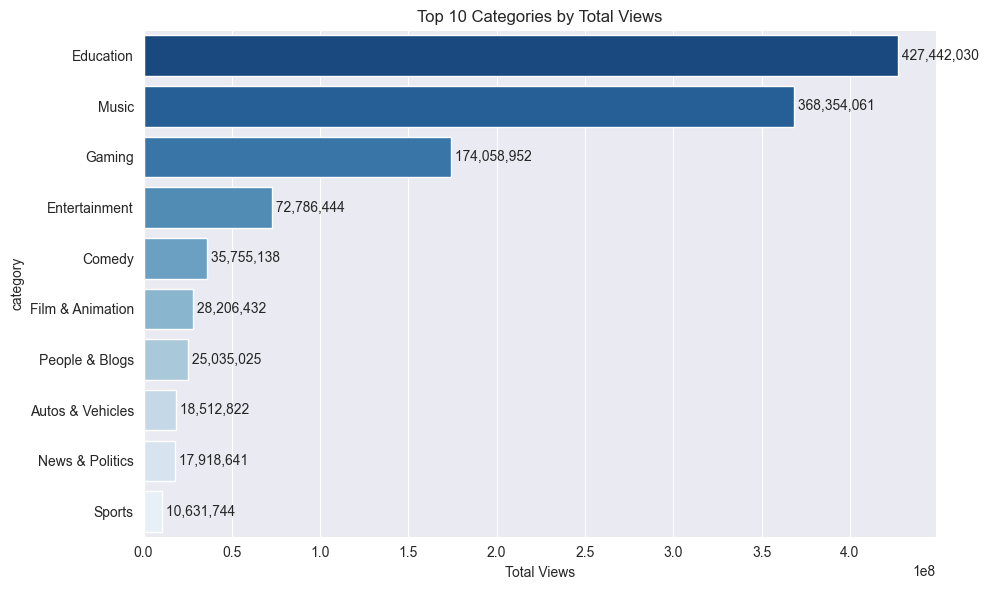

In [129]:
category_views = df.groupby('category')['views'].sum().sort_values(ascending=False)
top_n = 10
top_views = category_views.head(top_n)

plt.figure(figsize=(10,6))
sns.barplot(x=top_views.values, y=top_views.index, palette='Blues_r')
plt.xlabel('Total Views')
plt.title(f'Top {top_n} Categories by Total Views')
for i, v in enumerate(top_views.values):
    plt.text(v, i, f" {v:,}", va='center')
plt.tight_layout()
plt.show()

/var/folders/06/55ncynjj69l30_gnnsnw6xv40000gn/T/ipykernel_12279/3911833545.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




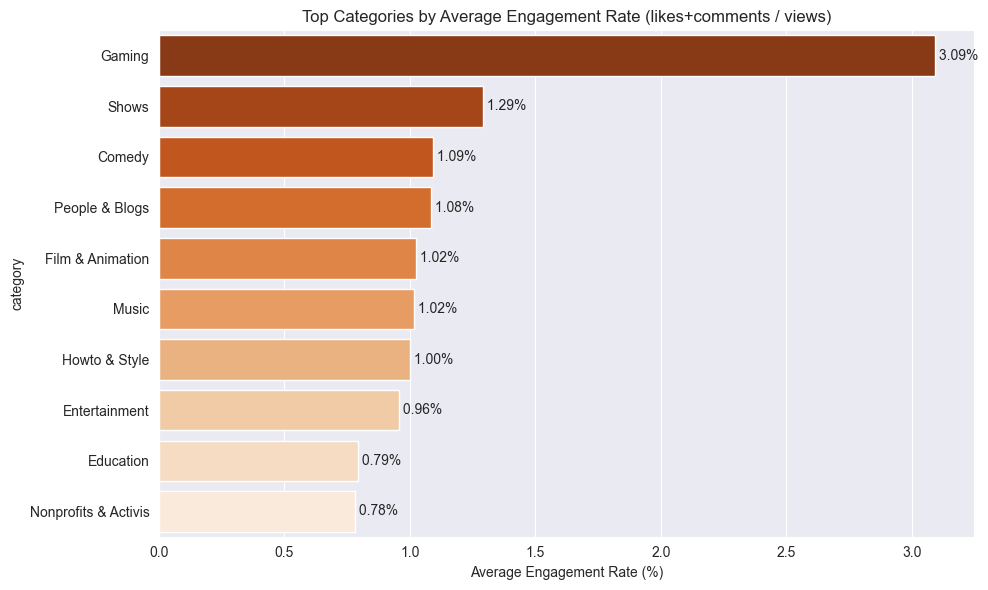

In [130]:
category_er = df.groupby('category')['engagement_rate'].mean().sort_values(ascending=False)
top_er = category_er.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_er.values * 100, y=top_er.index, palette='Oranges_r')
plt.xlabel('Average Engagement Rate (%)')
plt.title('Top Categories by Average Engagement Rate (likes+comments / views)')
for i, v in enumerate(top_er.values * 100):
    plt.text(v, i, f" {v:.2f}%", va='center')
plt.tight_layout()
plt.show()

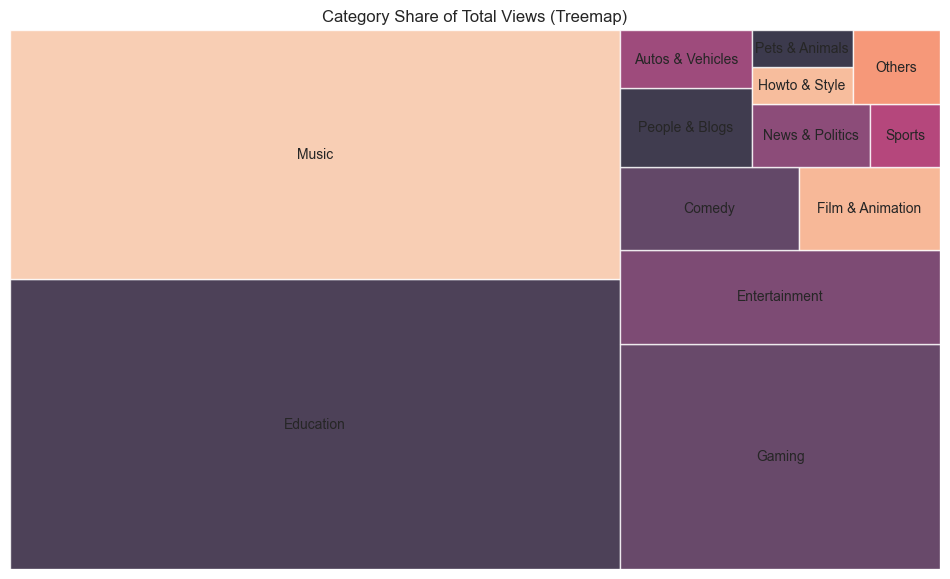

In [131]:
import squarify

cat_share = category_views.reset_index()
cat_share.columns = ['category', 'total_views']
# Optionally combine small categories into "Others"
top_n = 12
top = cat_share.head(top_n)
others = pd.DataFrame([{'category':'Others', 'total_views': cat_share['total_views'][top_n:].sum()}])
plot_data = pd.concat([top, others], ignore_index=True)

plt.figure(figsize=(12,7))
squarify.plot(sizes=plot_data['total_views'], label=plot_data['category'], alpha=0.8)
plt.axis('off')
plt.title('Category Share of Total Views (Treemap)')
plt.show()

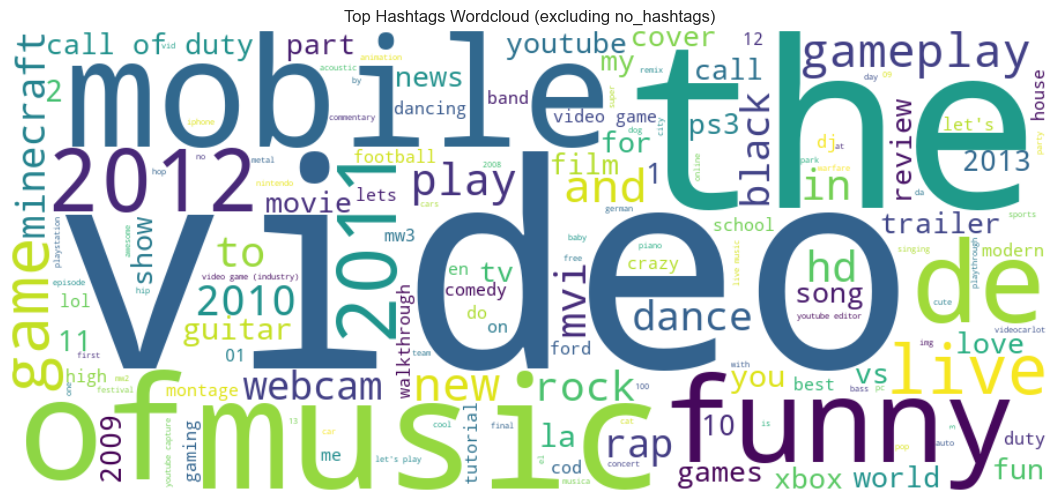

In [132]:
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# Build frequency ignoring 'no_hashtags'
hashtags_only = df[df['hashtags'] != 'no_hashtags']['hashtags'].dropna().astype(str)
# split multi-hashtags comma separated — adapt if other delimiter
# many rows contain comma-separated lists
tokens = []
for s in hashtags_only:
    # split by comma or whitespace (adjust if dataset uses other separators)
    parts = [p.strip() for p in s.replace(';', ',').split(',') if p.strip()!='']
    tokens.extend(parts)

freq = Counter(tokens)
# choose top_k
top_k = 150
wc = WordCloud(width=900, height=400, background_color='white', collocations=False).generate_from_frequencies(dict(freq.most_common(top_k)))

plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Top Hashtags Wordcloud (excluding no_hashtags)')
plt.show()

In [133]:
category_stats = (
    df.groupby('category')[['views', 'likes', 'comments', 'engagement_rate']]
      .mean()
      .sort_values(by='views', ascending=False)
)

# pretty print
pd.options.display.float_format = '{:,.2f}'.format
print(category_stats.round(2))

                          views    likes  comments  engagement_rate
category                                                           
Education            663,729.86   784.61     11.49             0.01
Shows                225,471.17 1,415.94    149.39             0.01
Music                124,192.20   481.93     30.20             0.01
Gaming               122,576.73   639.08     14.51             0.03
Film & Animation      48,051.84   205.25     25.43             0.01
Entertainment         32,349.53    56.55     10.64             0.01
Comedy                30,404.03    84.11     10.20             0.01
News & Politics       28,173.96   240.82     33.01             0.01
Howto & Style         27,069.09   104.46     11.05             0.01
Autos & Vehicles      23,199.03    35.76      5.82             0.00
Pets & Animals        18,896.29    57.54      6.66             0.01
Science & Technology  12,295.58    27.84      4.31             0.01
Travel & Events       11,664.86    27.80      3.

In [134]:
import plotly.express as px

fig = px.bar(
    category_views.reset_index().head(15),
    x='views',
    y='category',
    orientation='h',
    title='Top 15 Categories by Total Views',
    labels={'views':'Total Views','category':'Category'}
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [135]:
tech_map = df.groupby('category')[['duration', 'bitrate(video)', 'frame rate(est.)']].mean().round(2)

tech_map.style.background_gradient(cmap='viridis')

,duration,bitrate(video),frame rate(est.)
category,,,
Autos & Vehicles,138.390000,1239.880000,8.500000
Comedy,139.540000,792.100000,8.350000
Education,429.190000,931.400000,8.050000
Entertainment,197.370000,1058.490000,8.740000
Film & Animation,225.100000,1053.600000,9.710000
Gaming,453.190000,1803.240000,16.120000
Howto & Style,216.520000,1179.750000,11.110000
Music,247.750000,956.170000,8.800000
News & Politics,278.170000,891.320000,5.890000


In [136]:
df.to_csv('../data/youtube_clean_dashboard.csv')

df

,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),codec,category,title,description,hashtags,views,likes,comments,has_hashtags,engagement_rate
0,180,"5,777.00","5,640.00",1920,1080,25.00,25.00,h264,News & Politics,«السودان ينتفض» أمام السفارة بالقاهرة,حرية سلام وعدالة، الثورة خيار الشعب.. بهذا اله...,"في, عسكري, حكم, حرية, بخصوص, المصري اليوم, الس...",4078,41,3,1,0.01
1,930,"1,195.00","1,001.00",1280,720,30.00,30.00,h264,Gaming,Pokemon Tower Defense Episodio 2,Espero que tenham gostado do video!,"pokémon (anime/manga franchise), pokémon (vide...",33,2,1,1,0.09
2,233,"3,028.00","2,833.00",1280,720,23.98,23.98,h264,Comedy,New Hip Hop - Kemo Treats - Pancakes,Download all our music for FREE just enter $0....,"breaking bad spoof, recipes, pancakes, canada,...",13227,135,17,1,0.01
3,562,431.00,300.00,320,240,29.97,0.00,h264,People & Blogs,Sister's Keeper Impression,A Review of the Shampoo Bar(Sunburst) and Dip ...,"natural hair, first impression, sister's keepe...",43,1,0,1,0.02
4,300,"3,087.00","2,929.00",1280,720,23.98,23.98,h264,Gaming,JBHAMMER777 (AKUMA) VS KtossPol Rank 1 (Vega)...,JBHAMMER777 is he strong enough to fight again...,"tokido, momochi, (ryu), ae, 11, at, piyoppia, ...",222,2,0,1,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17581,571,"1,285.00","1,175.00",640,480,29.92,0.00,h264,People & Blogs,rentero 1ª parte 2.MOD,No description,"rentero, latapialinares, iu, pca",27,0,0,1,0.00
17582,105,840.00,719.00,640,480,29.97,0.00,h264,People & Blogs,Cascavel faz campanha impecável em campeonato ...,No description,no_hashtags,295,1,0,0,0.00
17583,161,920.00,820.00,640,480,29.97,0.00,h264,People & Blogs,Marcha para Cristo.San Francisco Menéndez. 5 ...,No description,"cristo, marcha, para",770,3,0,1,0.00
17584,291,"4,892.00","4,738.00",1920,1080,29.97,29.97,h264,Gaming,DK Solo Steinerne Kern,"Das ist mein erstes Video, also ist noch alles...","steinerne kern, vitriolsteindrachen, dk solo, ...",42,1,0,1,0.02
